# Asymptotic early-time model

In [ ]:
from functools import partial
import numpy as np
from lucifex.fdm import GridFunctionSeries, NPyConstantSeries
from lucifex.fem import grid_average
from lucifex.viz import (
    plot_colormap, plot_line, save_figure, create_multifigure,
    plot_colormap_multifigure, plot_line_multifigure,
)
from lucifex.utils.array_utils import as_index
from lucifex.io import create_dir_path, find_dir_paths
from lucifex.utils.py_utils import FrozenDict
from lucifex.sim import GridSimulationFromNPZ
from crocodil.dns.system_a import SYSTEM_A_REFERENCE
from crocodil.theory.system_a.early import EarlyTimeSimilarityModel
from ipynb_utils import as_int_if_poss

# searching for any simulations in the root directory
PARAMS_NUMERICAL = FrozenDict(
    c_stabilization=None,
    c_limits=True,
)
DIR_ROOT = create_dir_path(
    PARAMS_NUMERICAL, 
    dir_root='./',
    dir_prefix='data', 
    dir_params=PARAMS_NUMERICAL.keys(), 
)
DIR_FIGS = f'{DIR_ROOT}/figures'

T_STOP = 120.0
sim_dir_paths = find_dir_paths(
    DIR_ROOT, 
    include=f't_stop={T_STOP}_*',
    contains=('CHECKPOINT.h5', 'c.npz'),
)

# selecting a batch of simulations
PARAMS_BATCH = SYSTEM_A_REFERENCE.replace(Ra=500)

simulations = GridSimulationFromNPZ.dict_from_dir_paths(
    ('Ra', 'Da'), 
    sim_dir_paths,
    ('c', 's'),
    ('f', 'mD', 'mC', 'uRMS'),
    PARAMS_BATCH,
    lazy=True,
    sorting=lambda d: dict(sorted(d.items(), reverse=False)),
)

# utilities for plotting
save_figure = partial(
    save_figure, 
    dir_path=DIR_FIGS, 
    prefix='early_similarity', 
    pickle=True,
    file_ext=('svg', 'png'),
)

In [ ]:
print('Before parameter selection')
for i in sim_dir_paths: print(i)
print('After parameter selection')
for i in simulations.values(): print(i.dir_path)

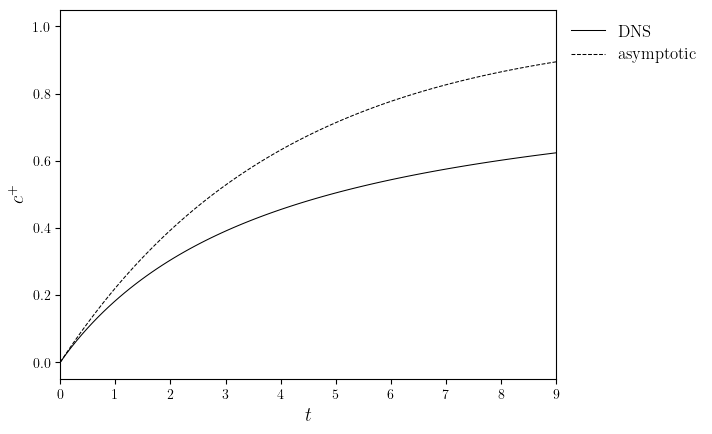

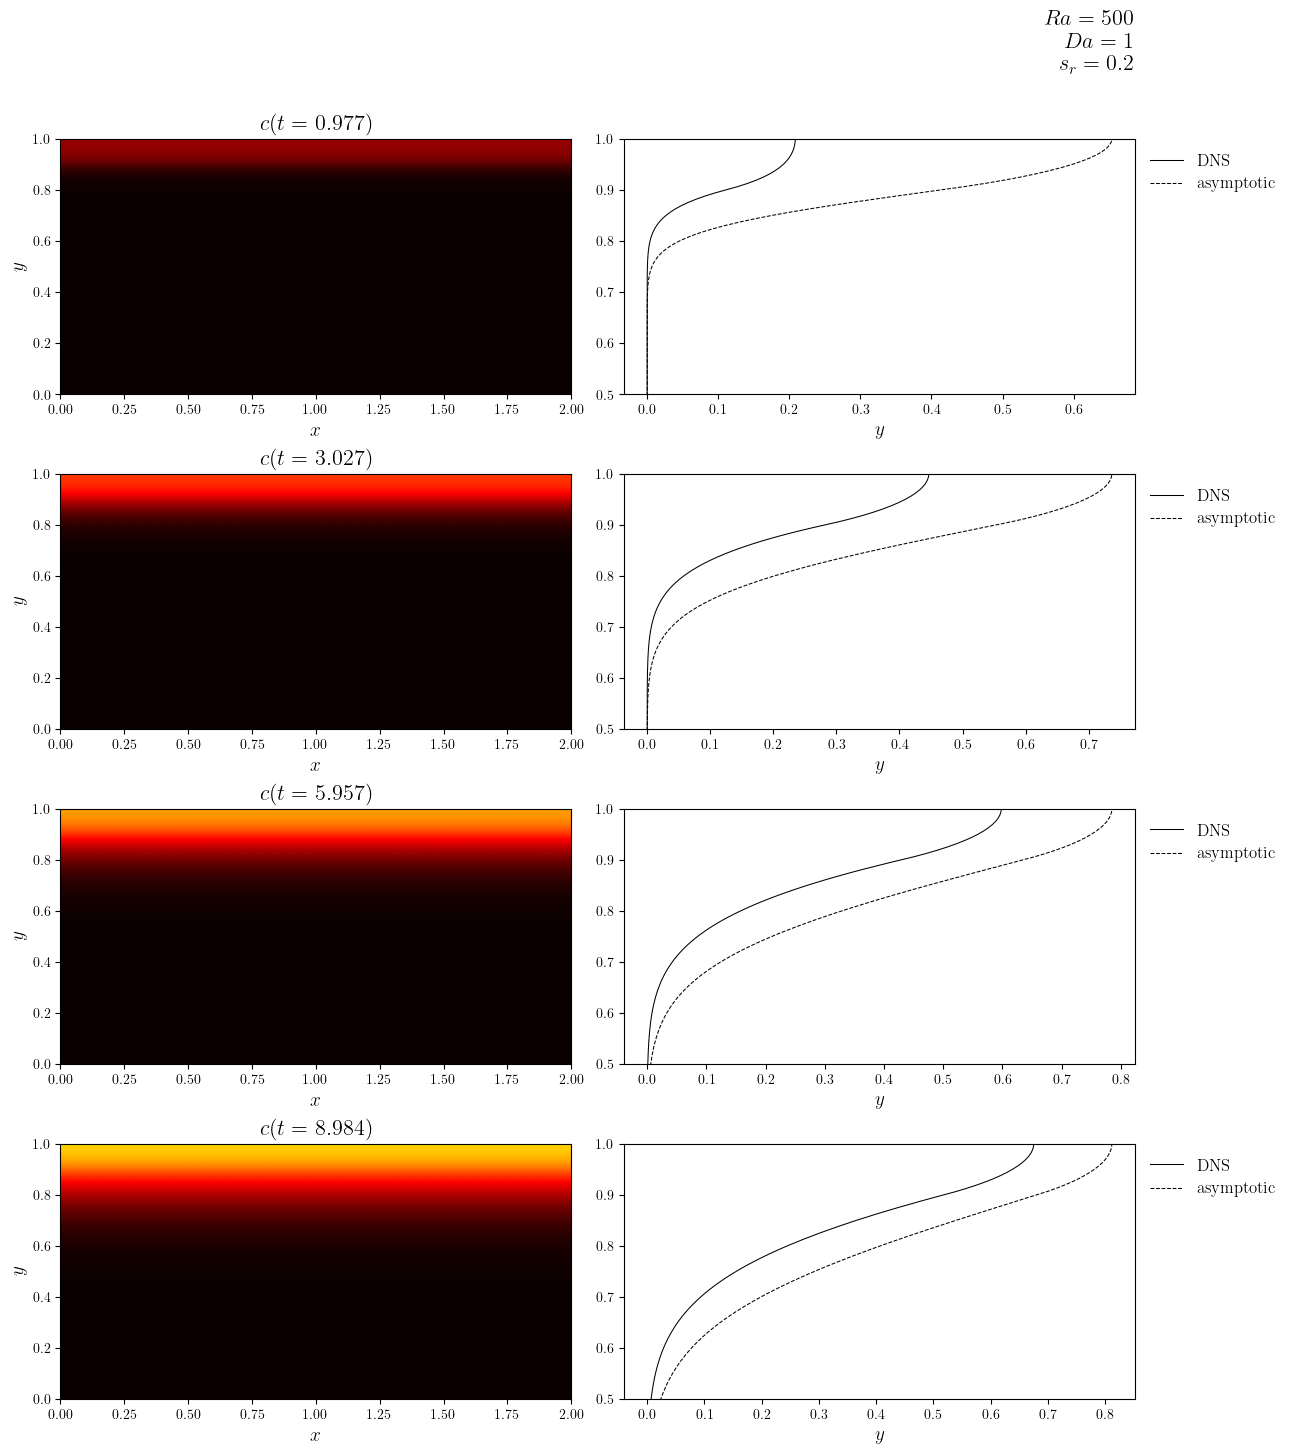

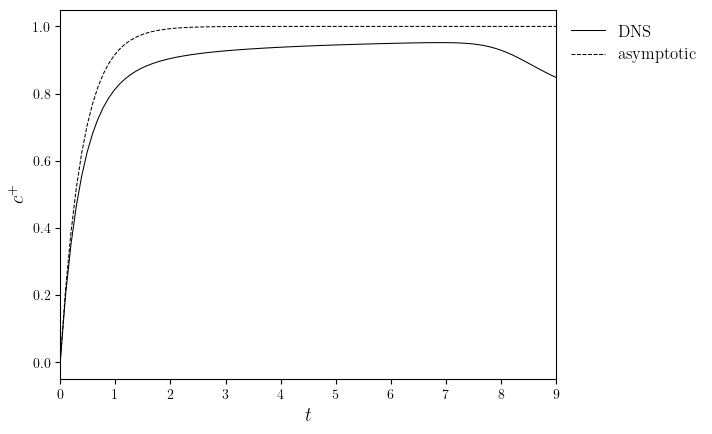

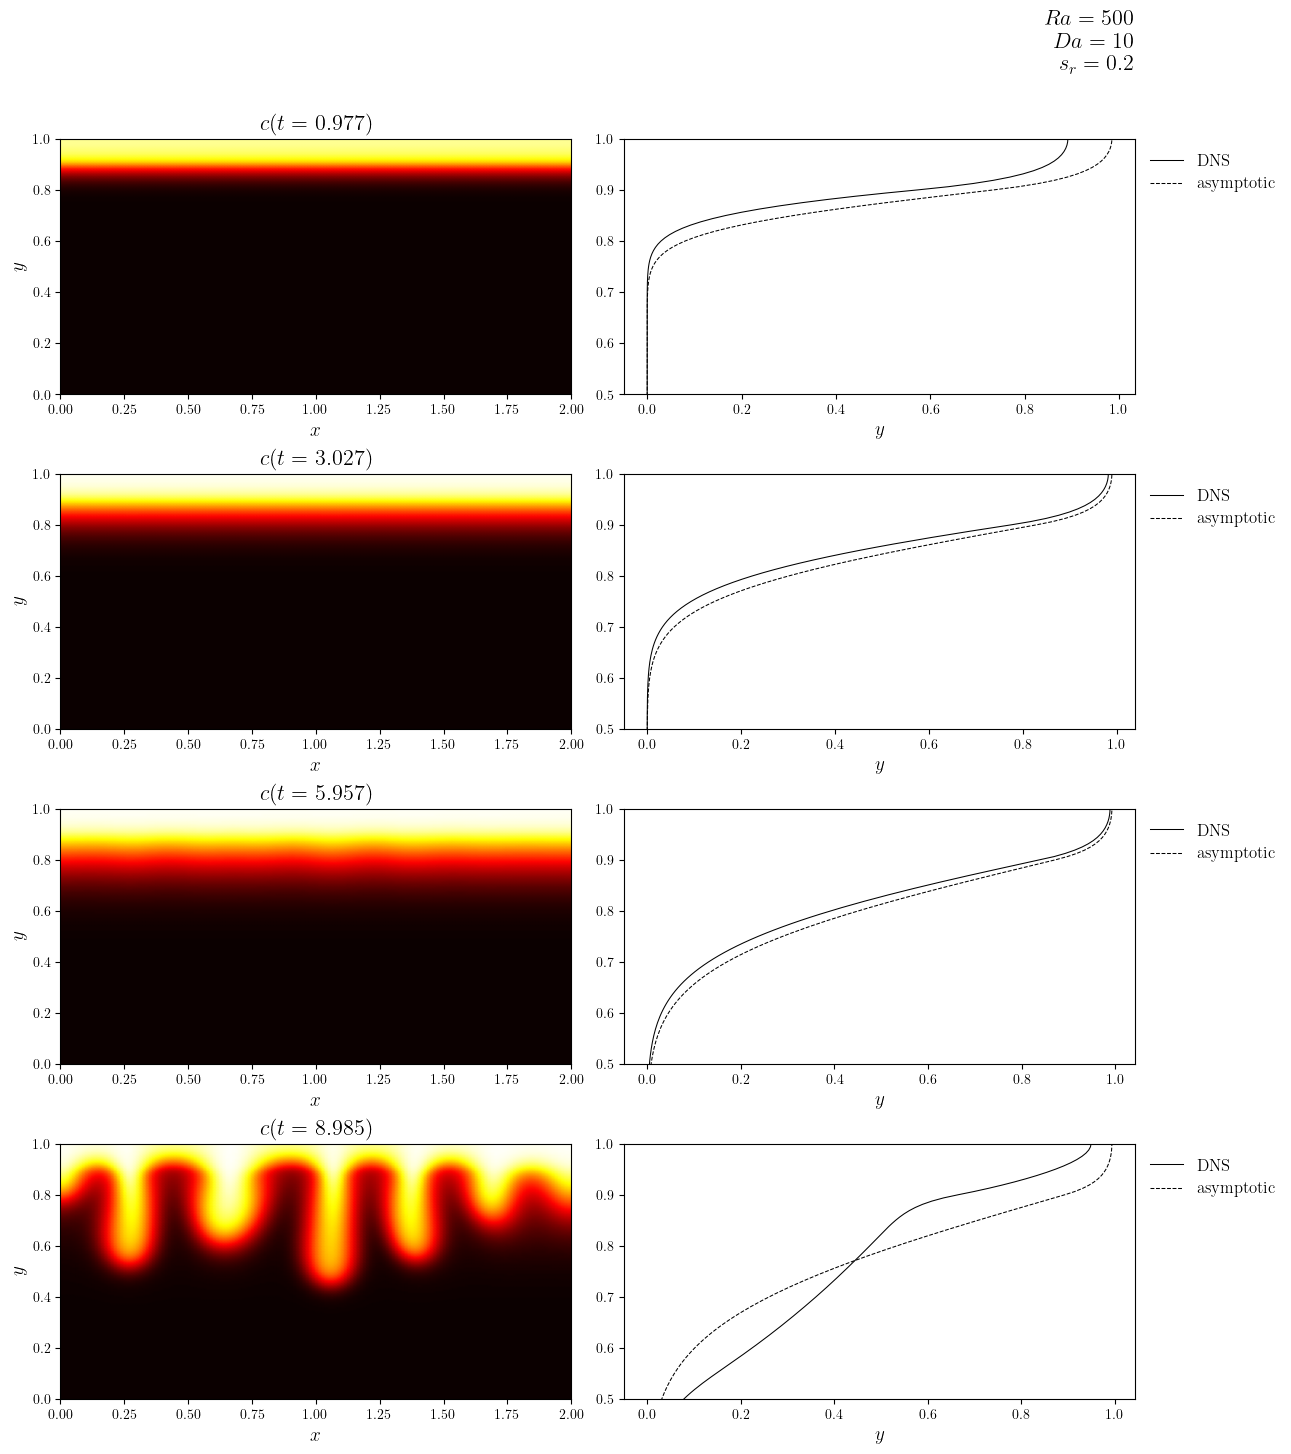

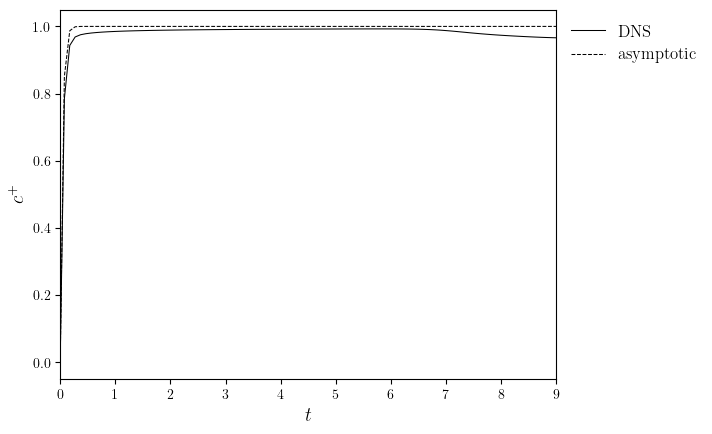

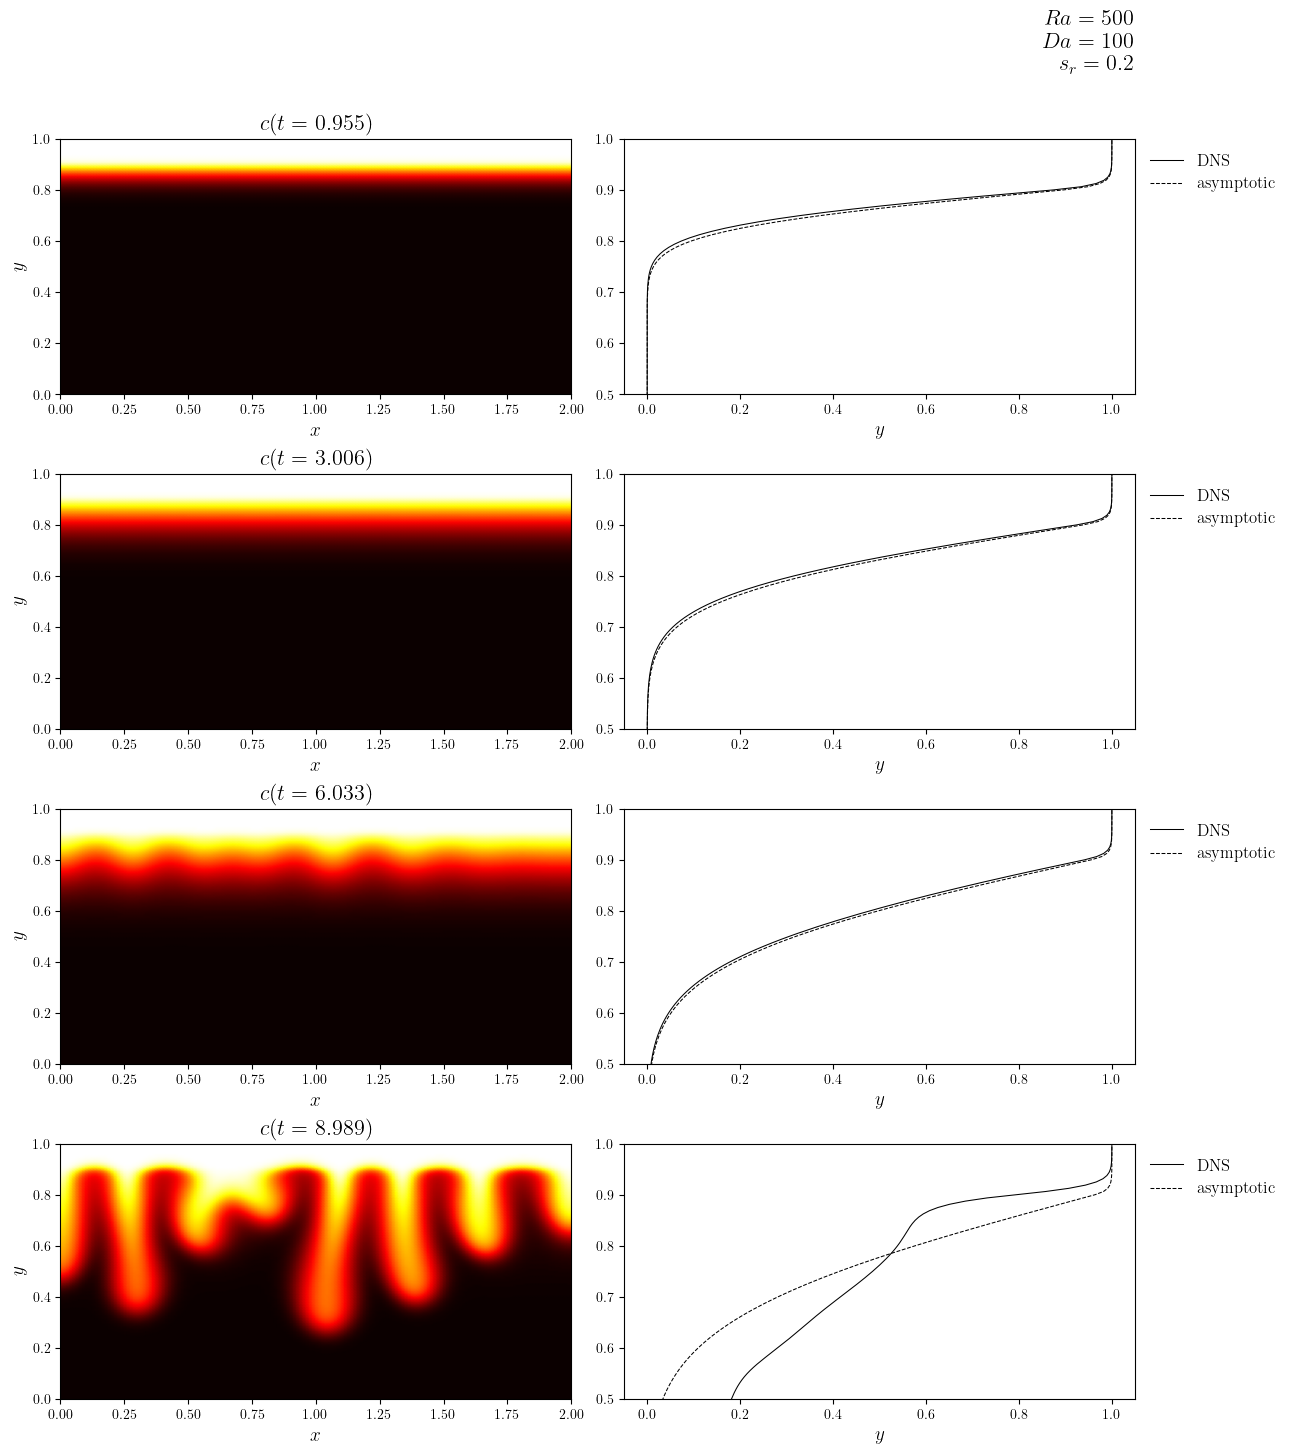

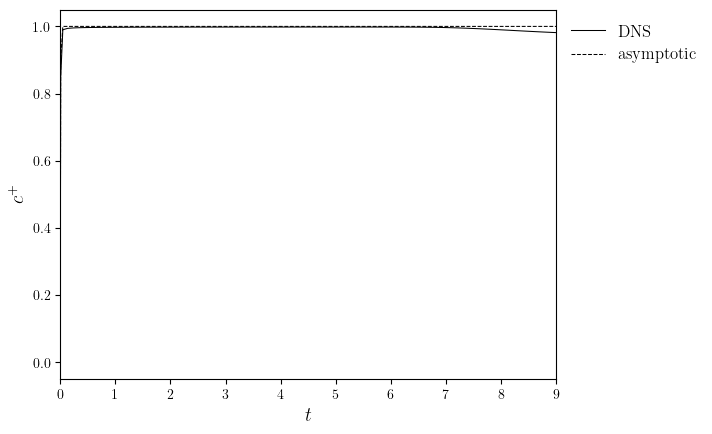

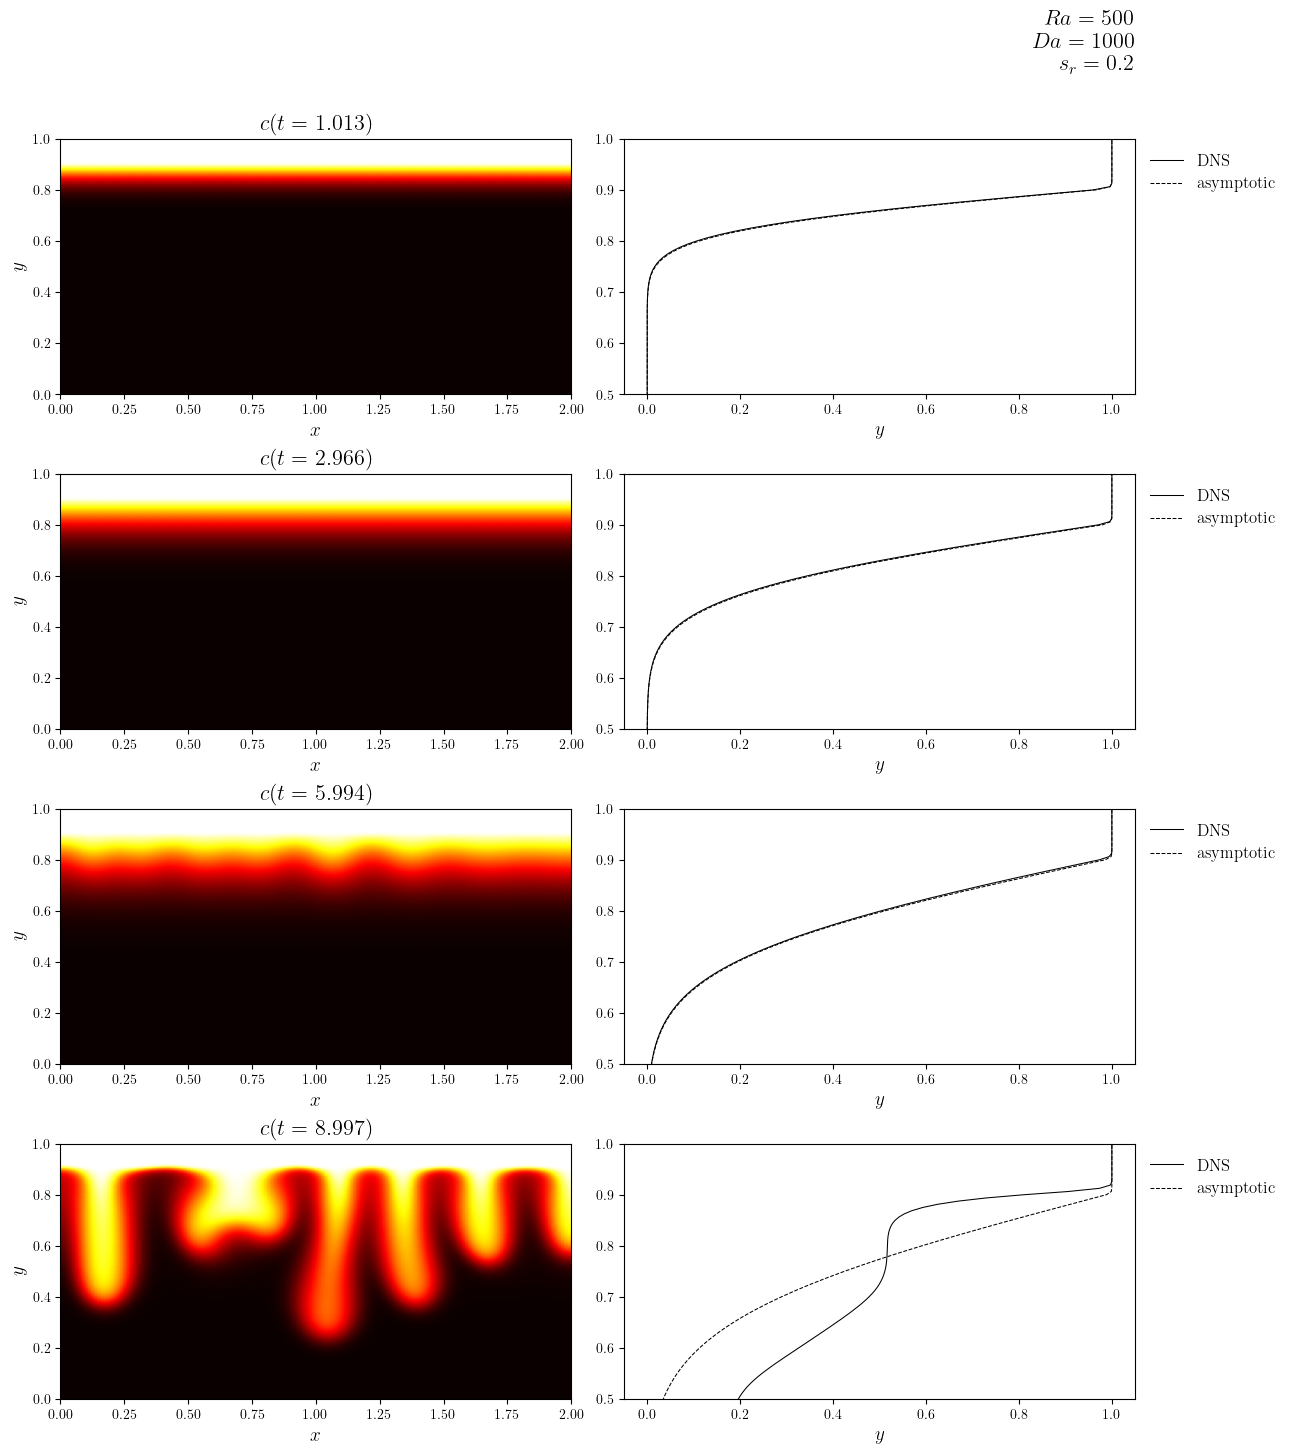

In [ ]:
t_targets = (1.0, 3.0, 6.0, 9.0)
Ra_targets = (500.0, )
Da_targets = None
include = lambda prm, trgs: prm in trgs if trgs else True

simulations_incl = {
    (Ra, Da): v for (Ra, Da), v in simulations.items()
    if include(Ra, Ra_targets) and include(Da, Da_targets)
}

legend_labels = ['DNS', 'similarity']

for (Ra, Da), sim in simulations_incl.items():
    c = sim['c']
    zeta0, sr, cr = sim['zeta0', 'sr', 'cr']
    zeta0_index = as_index(c.mesh.y_axis, zeta0)
    slcPlus = slice(zeta0_index, None)
    cPlus = NPyConstantSeries(
        grid_average(c.series, ('x', 'y'), (':', slcPlus)), c.time_series, 'cPlus',
    )
    asymp_model = EarlyTimeSimilarityModel(
        c.time_series, c.mesh.y_axis, 1/Ra, Da, zeta0, sr, cr, infty=False,
    )
    fig, ax = plot_line(
        [(cPlus.time_series, cPlus.value_series), (asymp_model.t, asymp_model.cPlus)],
        x_label='$t$',
        y_label='$c^+$',
        legend_labels=legend_labels,
        x_lims=(0, max(t_targets)), #(0, 10 / asymp_model.Pi)
    )
    mfig, axs_main, _ = create_multifigure(
        n_rows=len(t_targets), n_cols=2,
        suptitle='\n'.join((
            f"$Ra={as_int_if_poss(sim['Ra'])}$",
            f"$Da={as_int_if_poss(sim['Da'])}$",
            f"$s_r={as_int_if_poss(sim['sr'])}$",
        ))
    )

    for i, trg in enumerate(t_targets):
        time_index = as_index(c.time_series, trg)
        t_actual = c.time_series[time_index]
        cAvgX = grid_average(use_cache=True)(c.series[time_index], 'x') 
        cModel = (asymp_model.y, asymp_model.c[time_index])
        plot_colormap(
            mfig, 
            axs_main[2 * i], 
            c.series[time_index], 
            colorbar=False,
            title=f"$c(t={t_actual:.3f})$",
            vmin=0,
            vmax=1,
        )
        plot_line(
            mfig, 
            axs_main[2 * i + 1], 
            [cAvgX, cModel], 
            legend_labels=legend_labels, 
            flip=True,
            x_label='$y$',
            y_lims=(0.5, 1.0),
        )

    if DIR_FIGS: save_figure(f'Ra={Ra}_Da={Da}_sr={sr}_c_cAvgX')(mfig, file_ext=('pdf', 'png'))



In [ ]:
import numpy as np
from lucifex.viz import plot_line
from crocodil.dns.system_a import SYSTEM_A_REFERENCE
from crocodil.theory.system_a.early import EarlyTimeSimilarityModel

X = 1
Ra, Da, zeta0, sr, cr, aspect = SYSTEM_A_REFERENCE['Ra', 'Da', 'zeta0', 'sr', 'cr', 'aspect']
t = np.linspace(1e-6, 120.0, 100)
y = np.linspace(0, X, 100)

asymp_model = EarlyTimeSimilarityModel(t, y, Ra, Da, zeta0, sr, cr)

slc = slice(0, None, 5)
plot_line(
    [(asymp_model.y, i) for i in asymp_model.c[slc]],
    cyc='jet',
    legend_title='$t$',
    legend_labels=(min(asymp_model.t), max(asymp_model.t)),
    flip=True,
)

plot_line(
    (asymp_model.t, asymp_model.cZeta),
)

plot_line(
    (asymp_model.t, asymp_model.cPlus),
)

In [ ]:
plot_line